# P6-B200 AllGather (NCCL_TESTS_SPLIT_MASK=0x7) - Latency & Bandwidth Roofline Model

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # repo root: roofline_model/ package
from roofline_model import parse_size_str, parse_bw_file, parse_nchannels_table
from roofline_model import (gcp_ag_ring_simple_busbw, gcp_ag_ring_ll_busbw,
                            gcp_ag_ring_ll128_busbw, PlatformConfig)
cfg = PlatformConfig.load('p6-b200')   # platform hardware params (NIC BW, 1 EFA rail, ...)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

DATA_DIR = '../gcp_AG_AR_results'

# Load nchannels table (AllGather section)
nch_table = parse_nchannels_table(os.path.join(DATA_DIR, 'P6-b200_nchannels_table.txt'), section='AllGather')

# Load AG data files (0x7)
ag_data = {}
for proto in ['simple', 'll', 'll128']:
    fname = f'gcp_AG_ring_{proto}_0x7.txt'
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.exists(fpath):
        ag_data[proto] = parse_bw_file(fpath)
        print(f"Loaded {fname}: {len(ag_data[proto])} rows")

# Nchannels column name mapping
nch_col_map = {
    'simple': '0x7 Ring Simple',
    'll': '0x7 Ring LL',
    'll128': '0x7 Ring LL128',
}

# Protocol-appropriate message size ranges
PROTO_SIZE_RANGES = {
    'simple': (512 * 1024, float('inf')),
    'll': (0, 8 * 1024),
    'll128': (8 * 1024, 512 * 1024),
}

print(f"\nNchannels table columns: {list(nch_table.keys())}")
for col in nch_table:
    print(f"  {col}: {len(nch_table[col])} entries")


Loaded gcp_AG_ring_simple_0x7.txt: 26 rows
Loaded gcp_AG_ring_ll_0x7.txt: 20 rows
Loaded gcp_AG_ring_ll128_0x7.txt: 26 rows

Nchannels table columns: ['0x7 Ring Simple', '0x7 Ring LL', '0x7 Ring LL128']
  0x7 Ring Simple: 21 entries
  0x7 Ring LL: 8 entries
  0x7 Ring LL128: 18 entries


In [2]:
# Hardware parameters (from config.json)
a = cfg.a_us          # inter-node RTT of small msg (fixed startup latency == alpha)
N_nodes = 16
n_gpus = cfg.n_gpus_per_node  # GPUs per node, but 0x7 means 1 GPU/node on ring
n_on_ring = N_nodes  # In 0x7 mode, ring has N_nodes participants (1 GPU per node)
NIC_BW = cfg.nic_bw_dual  # bytes/us

# AllGather busbw_factor = (n-1)/n (unlike AllReduce which is 2*(n-1)/n)
busbw_factor = (n_on_ring - 1) / n_on_ring

print(f"a (inter-node RTT, from config) = {a:.4f} us")
print(f"N_nodes = {N_nodes}, n_on_ring = {n_on_ring}")
print(f"NIC_BW = {NIC_BW:.0f} bytes/us = {NIC_BW/1e3:.2f} GB/s")
print(f"busbw_factor = (n-1)/n = {busbw_factor:.4f}")

a (inter-node RTT, fixed from mean of msg <= 32B) = 30.6633 us
N_nodes = 16, n_on_ring = 16
NIC_BW = 48750 bytes/us = 48.75 GB/s
busbw_factor = (n-1)/n = 0.9375


Ring/Simple AllGather (N=16):
  G = (n-1)/(n*NIC_BW) = 1.923077e-05 us/byte
  fixed_per_step = (n-1)*a/2 = 229.98 us
  Ideal peak busBW = 48.75 GB/s

      Size  nch   AWS BW   GCP BW  Roofline
--------------------------------------------------
     0.5MB    4     1.22     3.19      2.05
     1.0MB    4     2.18     6.88      3.93
     2.0MB    4     3.66    12.99      7.27
     4.0MB    4     7.27    22.20     12.66
     8.0MB    4    13.88    23.81     20.10
    16.0MB    4    22.91    29.32     28.46
    32.0MB    4    33.69    39.19     35.94
    64.0MB    4    39.68    43.13     41.38
   128.0MB    4    44.98    44.58     44.76
   256.0MB    4    45.62    45.24     46.67
   512.0MB    4    46.38    45.45     46.67
  1024.0MB    4    46.81    45.55     46.67
  2048.0MB    4    47.01    45.71     46.67
  4096.0MB    4    47.27    45.75     46.67
  8192.0MB    4    47.44    45.85     46.67


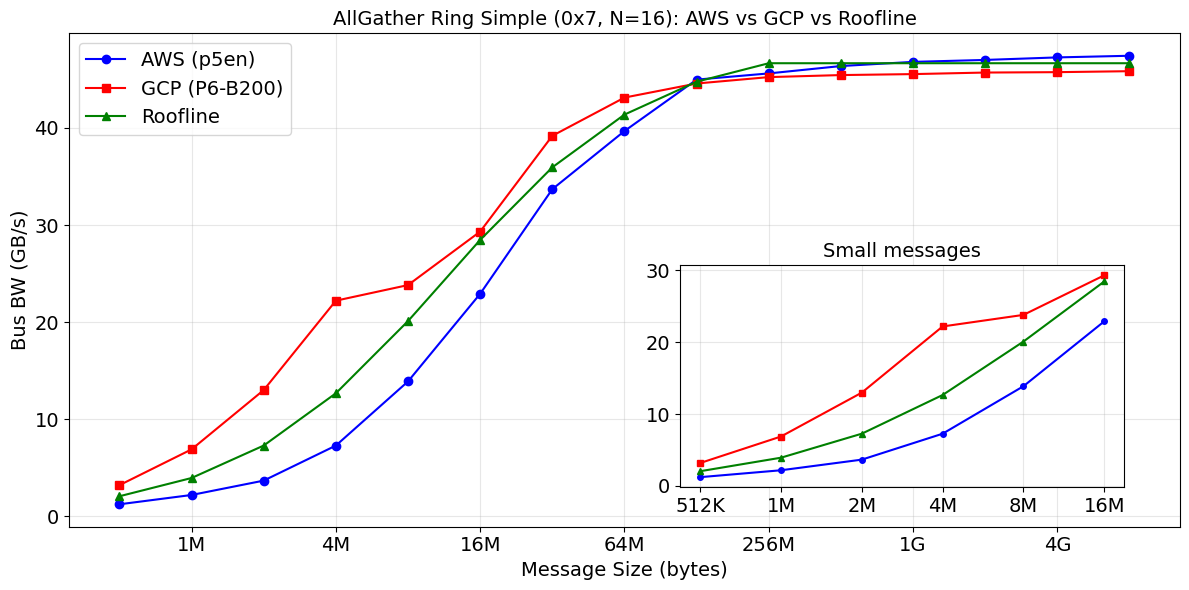

In [3]:
# X-axis ticks as powers of 2
import matplotlib.ticker as ticker
def format_size(x, p):
    if x <= 0:
        return ''
    if x < 1024:
        return f'{int(x)}B'
    elif x < 1024**2:
        v = x / 1024
        return f'{int(v)}K' if v == int(v) else ''
    elif x < 1024**3:
        v = x / 1024**2
        return f'{int(v)}M' if v == int(v) else ''
    else:
        v = x / 1024**3
        return f'{int(v)}G' if v == int(v) else ''

# Ring/Simple AllGather roofline
G_simple = (n_on_ring - 1) / (n_on_ring * NIC_BW)
fixed_per_step_simple = (n_on_ring - 1) * a / 2

nch_col = nch_col_map['simple']
df = ag_data['simple'].copy()
_lo, _hi = PROTO_SIZE_RANGES['simple']
df = df[(df['size_bytes'] >= _lo) & (df['size_bytes'] <= _hi)].copy()

df['nch_raw'] = df['size_bytes'].map(lambda s: nch_table[nch_col].get(s, 4))
sizes = df['size_bytes'].values
nch = df['nch_raw'].values

df['roofline_busbw'] = gcp_ag_ring_simple_busbw(sizes, nch, n_on_ring, a, busbw_factor, cfg=cfg)

print(f"Ring/Simple AllGather (N={N_nodes}):")
print(f"  G = (n-1)/(n*NIC_BW) = {G_simple:.6e} us/byte")
print(f"  fixed_per_step = (n-1)*a/2 = {fixed_per_step_simple:.2f} us")
print(f"  Ideal peak busBW = {1/G_simple/1e3 * busbw_factor:.2f} GB/s")
print(f"\n{'Size':>10} {'nch':>4} {'AWS BW':>8} {'GCP BW':>8} {'Roofline':>9}")
print("-" * 50)
for _, row in df.iterrows():
    aws = f"{row['aws_busbw']:.2f}" if row['aws_busbw'] is not None else "—"
    gcp = f"{row['gcp_busbw']:.2f}" if row['gcp_busbw'] is not None else "—"
    size_mb = row['size_bytes'] / (1024**2)
    print(f"{size_mb:>8.1f}MB {int(row['nch_raw']):>4} {aws:>8} {gcp:>8} {row['roofline_busbw']:>9.2f}")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mask_aws = df['aws_busbw'].notna()
mask_gcp = df['gcp_busbw'].notna()
if mask_aws.any():
    ax.semilogx(df.loc[mask_aws, 'size_bytes'], df.loc[mask_aws, 'aws_busbw'], 'bo-', label='AWS (p5en)', ms=6)
if mask_gcp.any():
    ax.semilogx(df.loc[mask_gcp, 'size_bytes'], df.loc[mask_gcp, 'gcp_busbw'], 'rs-', label='GCP (P6-B200)', ms=6)
ax.semilogx(df['size_bytes'], df['roofline_busbw'], 'g^-', label='Roofline', ms=6)
ax.set_xlabel('Message Size (bytes)', fontsize=14)
ax.set_ylabel('Bus BW (GB/s)', fontsize=14)
ax.set_title(f'AllGather Ring Simple (0x7, N={N_nodes}): AWS vs GCP vs Roofline', fontsize=14)
ax.legend(loc='upper left', fontsize=14); ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=14)

# Inset for small messages
sizes_sorted = df['size_bytes'].sort_values().values
if len(sizes_sorted) > 4:
    inset_cutoff = sizes_sorted[len(sizes_sorted) // 3]
    df_inset = df[df['size_bytes'] <= inset_cutoff]
    if len(df_inset) > 1:
        axins = ax.inset_axes([0.55, 0.08, 0.4, 0.45])
        mask_aws_in = df_inset['aws_busbw'].notna()
        mask_gcp_in = df_inset['gcp_busbw'].notna()
        if mask_aws_in.any():
            axins.semilogx(df_inset.loc[mask_aws_in, 'size_bytes'], df_inset.loc[mask_aws_in, 'aws_busbw'], 'bo-', ms=4)
        if mask_gcp_in.any():
            axins.semilogx(df_inset.loc[mask_gcp_in, 'size_bytes'], df_inset.loc[mask_gcp_in, 'gcp_busbw'], 'rs-', ms=4)
        axins.semilogx(df_inset['size_bytes'], df_inset['roofline_busbw'], 'g^-', ms=4)
        axins.set_title('Small messages', fontsize=14)
        axins.tick_params(labelsize=14)
        axins.xaxis.set_major_locator(ticker.LogLocator(base=2))
        axins.xaxis.set_major_formatter(ticker.FuncFormatter(format_size))
        axins.xaxis.set_minor_locator(ticker.NullLocator())
        axins.grid(True, alpha=0.3)


ax.xaxis.set_major_locator(ticker.LogLocator(base=2))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_size))
ax.xaxis.set_minor_locator(ticker.NullLocator())

plt.tight_layout(); plt.show()


Ring/LL AllGather (N=16, chunk=32KB):

      Size  nch   AWS BW   GCP BW  Roofline
--------------------------------------------------
       256    1     0.00      nan      0.00
       512    1     0.00      nan      0.00
      1024    1     0.00      nan      0.00
      2048    1     0.01      nan      0.01
      4096    1     0.02     0.02      0.02
      8192    1     0.04     0.05      0.03


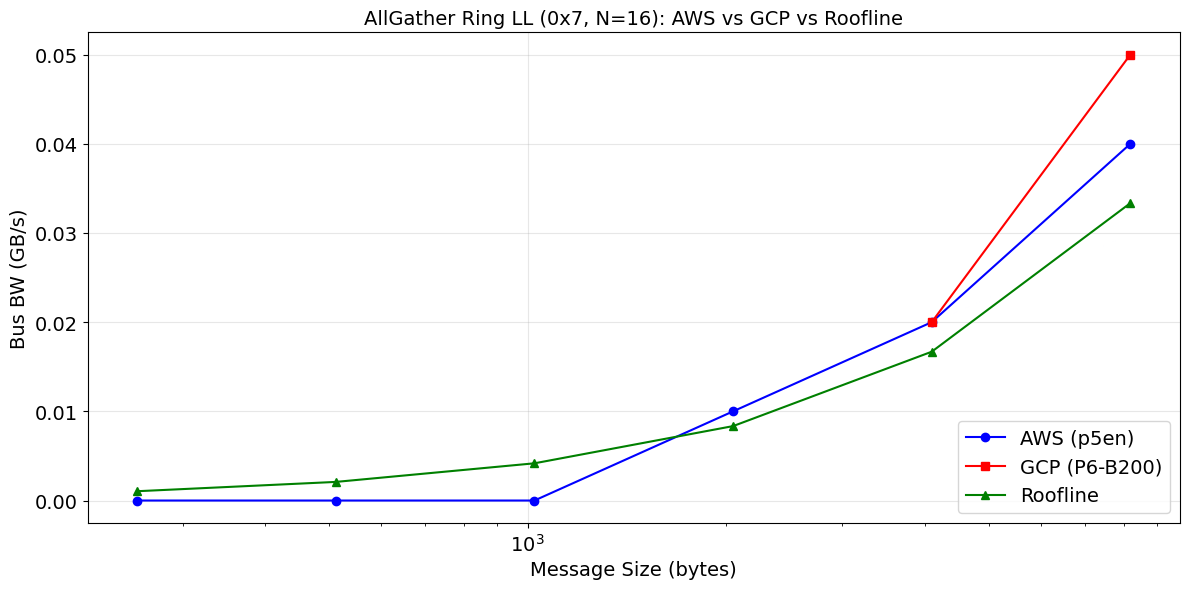

In [4]:
# Ring/LL AllGather roofline
chunk_ll = 32 * 1024

nch_col = nch_col_map['ll']
df_ll = ag_data['ll'].copy()
_lo, _hi = PROTO_SIZE_RANGES['ll']
df_ll = df_ll[(df_ll['size_bytes'] >= _lo) & (df_ll['size_bytes'] <= _hi)].copy()

df_ll['nch_raw'] = df_ll['size_bytes'].map(lambda s: nch_table[nch_col].get(s, 1))
sizes = df_ll['size_bytes'].values
nch = df_ll['nch_raw'].values

df_ll['roofline_busbw'] = gcp_ag_ring_ll_busbw(sizes, nch, n_on_ring, a, busbw_factor, cfg=cfg)

print(f"Ring/LL AllGather (N={N_nodes}, chunk={chunk_ll//1024}KB):")
print(f"\n{'Size':>10} {'nch':>4} {'AWS BW':>8} {'GCP BW':>8} {'Roofline':>9}")
print("-" * 50)
for _, row in df_ll.iterrows():
    aws = f"{row['aws_busbw']:.2f}" if row['aws_busbw'] is not None else "—"
    gcp = f"{row['gcp_busbw']:.2f}" if row['gcp_busbw'] is not None else "—"
    print(f"{int(row['size_bytes']):>10} {int(row['nch_raw']):>4} {aws:>8} {gcp:>8} {row['roofline_busbw']:>9.2f}")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mask_aws = df_ll['aws_busbw'].notna()
mask_gcp = df_ll['gcp_busbw'].notna()
if mask_aws.any():
    ax.semilogx(df_ll.loc[mask_aws, 'size_bytes'], df_ll.loc[mask_aws, 'aws_busbw'], 'bo-', label='AWS (p5en)', ms=6)
if mask_gcp.any():
    ax.semilogx(df_ll.loc[mask_gcp, 'size_bytes'], df_ll.loc[mask_gcp, 'gcp_busbw'], 'rs-', label='GCP (P6-B200)', ms=6)
ax.semilogx(df_ll['size_bytes'], df_ll['roofline_busbw'], 'g^-', label='Roofline', ms=6)
ax.set_xlabel('Message Size (bytes)', fontsize=14)
ax.set_ylabel('Bus BW (GB/s)', fontsize=14)
ax.set_title(f'AllGather Ring LL (0x7, N={N_nodes}): AWS vs GCP vs Roofline', fontsize=14)
ax.legend(loc='lower right', fontsize=14); ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=14)

plt.tight_layout(); plt.show()


Ring/LL128 AllGather (N=16, chunk=576000 bytes):

      Size  nch   AWS BW   GCP BW  Roofline
--------------------------------------------------
      8192    1     0.03     0.04      0.03
     16384    1     0.06     0.07      0.07
     32768    1     0.12     0.14      0.13
     65536    2     0.23     0.27      0.27
    131072    4     0.45     0.55      0.53
    262144    4     0.85     1.08      1.04
    524288    4     1.60     2.07      2.04


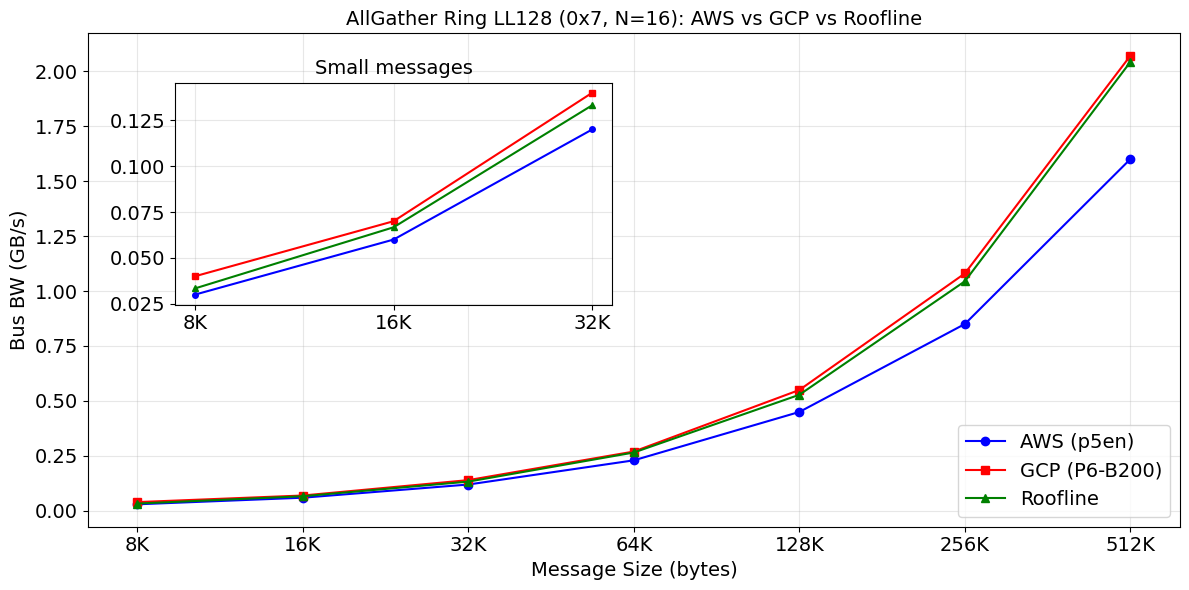

In [5]:
# X-axis ticks as powers of 2
import matplotlib.ticker as ticker
def format_size(x, p):
    if x <= 0:
        return ''
    if x < 1024:
        return f'{int(x)}B'
    elif x < 1024**2:
        v = x / 1024
        return f'{int(v)}K' if v == int(v) else ''
    elif x < 1024**3:
        v = x / 1024**2
        return f'{int(v)}M' if v == int(v) else ''
    else:
        v = x / 1024**3
        return f'{int(v)}G' if v == int(v) else ''

# Ring/LL128 AllGather roofline
chunk_ll128 = 576000

nch_col = nch_col_map['ll128']
df_ll128 = ag_data['ll128'].copy()
_lo, _hi = PROTO_SIZE_RANGES['ll128']
df_ll128 = df_ll128[(df_ll128['size_bytes'] >= _lo) & (df_ll128['size_bytes'] <= _hi)].copy()

df_ll128['nch_raw'] = df_ll128['size_bytes'].map(lambda s: nch_table[nch_col].get(s, 4))
sizes = df_ll128['size_bytes'].values
nch = df_ll128['nch_raw'].values

df_ll128['roofline_busbw'] = gcp_ag_ring_ll128_busbw(sizes, nch, n_on_ring, a, busbw_factor, cfg=cfg)

print(f"Ring/LL128 AllGather (N={N_nodes}, chunk={chunk_ll128} bytes):")
print(f"\n{'Size':>10} {'nch':>4} {'AWS BW':>8} {'GCP BW':>8} {'Roofline':>9}")
print("-" * 50)
for _, row in df_ll128.iterrows():
    aws = f"{row['aws_busbw']:.2f}" if row['aws_busbw'] is not None else "—"
    gcp = f"{row['gcp_busbw']:.2f}" if row['gcp_busbw'] is not None else "—"
    print(f"{int(row['size_bytes']):>10} {int(row['nch_raw']):>4} {aws:>8} {gcp:>8} {row['roofline_busbw']:>9.2f}")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mask_aws = df_ll128['aws_busbw'].notna()
mask_gcp = df_ll128['gcp_busbw'].notna()
if mask_aws.any():
    ax.semilogx(df_ll128.loc[mask_aws, 'size_bytes'], df_ll128.loc[mask_aws, 'aws_busbw'], 'bo-', label='AWS (p5en)', ms=6)
if mask_gcp.any():
    ax.semilogx(df_ll128.loc[mask_gcp, 'size_bytes'], df_ll128.loc[mask_gcp, 'gcp_busbw'], 'rs-', label='GCP (P6-B200)', ms=6)
ax.semilogx(df_ll128['size_bytes'], df_ll128['roofline_busbw'], 'g^-', label='Roofline', ms=6)
ax.set_xlabel('Message Size (bytes)', fontsize=14)
ax.set_ylabel('Bus BW (GB/s)', fontsize=14)
ax.set_title(f'AllGather Ring LL128 (0x7, N={N_nodes}): AWS vs GCP vs Roofline', fontsize=14)
ax.legend(loc='lower right', fontsize=14); ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=14)

sizes_sorted = df_ll128['size_bytes'].sort_values().values
if len(sizes_sorted) > 4:
    inset_cutoff = sizes_sorted[len(sizes_sorted) // 3]
    df_inset = df_ll128[df_ll128['size_bytes'] <= inset_cutoff]
    if len(df_inset) > 1:
        axins = ax.inset_axes([0.08, 0.45, 0.4, 0.45])
        mask_aws_in = df_inset['aws_busbw'].notna()
        mask_gcp_in = df_inset['gcp_busbw'].notna()
        if mask_aws_in.any():
            axins.semilogx(df_inset.loc[mask_aws_in, 'size_bytes'], df_inset.loc[mask_aws_in, 'aws_busbw'], 'bo-', ms=4)
        if mask_gcp_in.any():
            axins.semilogx(df_inset.loc[mask_gcp_in, 'size_bytes'], df_inset.loc[mask_gcp_in, 'gcp_busbw'], 'rs-', ms=4)
        axins.semilogx(df_inset['size_bytes'], df_inset['roofline_busbw'], 'g^-', ms=4)
        axins.set_title('Small messages', fontsize=14)
        axins.tick_params(labelsize=14)
        axins.xaxis.set_major_locator(ticker.LogLocator(base=2))
        axins.xaxis.set_major_formatter(ticker.FuncFormatter(format_size))
        axins.xaxis.set_minor_locator(ticker.NullLocator())
        axins.grid(True, alpha=0.3)


ax.xaxis.set_major_locator(ticker.LogLocator(base=2))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_size))
ax.xaxis.set_minor_locator(ticker.NullLocator())

plt.tight_layout(); plt.show()
